# Citi Bike Rebalancing-01
This notebook prepares the Citi Bike data used in the reinforcement learning experiments.

The main steps are:

1. Load and combine monthly NYC Citi Bike trip files from January 2025 to February 2026. Then cleaned and aggregated into hourly departures and arrivals for the two selected stations.
2. Create exploratory visualizations to show station-level demand imbalance and the need for rebalancing.
3. Split hourly data into `train_hourly` and `test_hourly`, then then saved for the later SARSA, Q-learning, and DQN notebooks.

The outputs of this notebook are:

- `train_hourly.csv`
- `test_hourly.csv`
- `station_info.csv`

These processed files are saved in `data/processed/` folder and used by the tabular RL and DQN notebooks.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

SEED = 42
np.random.seed(SEED)

RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

## Data processing

**1. Load and combine history data**

In [2]:
file_names = [
    "JC-202501-citibike-tripdata.csv",
    "JC-202502-citibike-tripdata.csv",
    "JC-202503-citibike-tripdata.csv",
    "JC-202504-citibike-tripdata.csv",
    "JC-202505-citibike-tripdata.csv",
    "JC-202506-citibike-tripdata.csv",
    "JC-202507-citibike-tripdata.csv",
    "JC-202508-citibike-tripdata.csv",
    "JC-202509-citibike-tripdata.csv",
    "JC-202510-citibike-tripdata.csv",
    "JC-202511-citibike-tripdata.csv",
    "JC-202512-citibike-tripdata.csv",
    "JC-202601-citibike-tripdata.csv",
    "JC-202602-citibike-tripdata.csv"]

df = pd.concat([pd.read_csv(RAW_DIR / file) for file in file_names],ignore_index=True)

print("Original shape:", df.shape)
df.head()

Original shape: (1068557, 13)


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,880A0159BA5275FB,electric_bike,2025-01-16 17:50:49.136,2025-01-16 17:57:00.710,Hilltop,JC019,Pershing Field,JC024,40.731169,-74.057574,40.742677,-74.051789,member
1,1A5E1E274B2AF0AD,electric_bike,2025-01-31 06:10:41.818,2025-01-31 06:22:09.499,Hilltop,JC019,Jackson Square,JC063,40.731169,-74.057574,40.711130,-74.078900,member
2,EA9928D3C05B8377,classic_bike,2025-01-09 16:42:50.213,2025-01-09 17:04:12.870,Hilltop,JC019,Hoboken Terminal - Hudson St & Hudson Pl,HB101,40.731169,-74.057574,40.735938,-74.030305,member
3,3C42C367750B9292,electric_bike,2025-01-21 16:14:14.398,2025-01-21 16:37:10.458,Hilltop,JC019,Hoboken Terminal - Hudson St & Hudson Pl,HB101,40.731169,-74.057574,40.735938,-74.030305,member
4,94D3B0265A7BDE1F,classic_bike,2025-01-30 16:38:18.840,2025-01-30 17:04:08.166,Hilltop,JC019,Hoboken Terminal - Hudson St & Hudson Pl,HB101,40.731169,-74.057574,40.735938,-74.030305,member


**2. Clean raw data**

In [3]:
# Convert time columns to datetime
df["started_at"] = pd.to_datetime(df["started_at"], errors="coerce")
df["ended_at"] = pd.to_datetime(df["ended_at"], errors="coerce")

# Keep trips from 2025-01-01 through 2026-02-28
df = df[(df["started_at"] >= "2025-01-01") &(df["started_at"] < "2026-03-01")].copy()

# Remove rows with missing critical information
df = df.dropna(subset=["ride_id", "started_at", "ended_at", "start_station_id", "end_station_id"]).copy()

# Remove duplicated rides
df = df.drop_duplicates(subset=["ride_id"]).copy()

# Keep only columns needed for the RL environment
df = df[["ride_id", "started_at", "ended_at", "start_station_id", "start_station_name", "end_station_id", "end_station_name"]].copy()

print("Cleaned shape:", df.shape)
df.head()

Cleaned shape: (1062914, 7)


,ride_id,started_at,ended_at,start_station_id,start_station_name,end_station_id,end_station_name
0,880A0159BA5275FB,2025-01-16 17:50:49.136,2025-01-16 17:57:00.710,JC019,Hilltop,JC024,Pershing Field
1,1A5E1E274B2AF0AD,2025-01-31 06:10:41.818,2025-01-31 06:22:09.499,JC019,Hilltop,JC063,Jackson Square
2,EA9928D3C05B8377,2025-01-09 16:42:50.213,2025-01-09 17:04:12.870,JC019,Hilltop,HB101,Hoboken Terminal - Hudson St & Hudson Pl
3,3C42C367750B9292,2025-01-21 16:14:14.398,2025-01-21 16:37:10.458,JC019,Hilltop,HB101,Hoboken Terminal - Hudson St & Hudson Pl
4,94D3B0265A7BDE1F,2025-01-30 16:38:18.840,2025-01-30 17:04:08.166,JC019,Hilltop,HB101,Hoboken Terminal - Hudson St & Hudson Pl


**3. Select 2 stations**

We selected two active but imbalanced stations based on the training period. We first kept only stations whose total activity was above the 80th percentile. Among these active stations, we selected the two stations with the largest absolute net flow (# departure - # arrival). This station selection strategy creates a setting where rebalancing is meaningful.

In [4]:
# Select stations using training data only, avoid data leakage
train_period_df = df.query('"2025-01-01" <= started_at < "2026-02-01"').copy()

# Count station-level activity
station_flow = pd.DataFrame({
    "departures": train_period_df["start_station_id"].value_counts(),
    "arrivals": train_period_df["end_station_id"].value_counts()
}).fillna(0)

station_flow["total_activity"] = station_flow["departures"] + station_flow["arrivals"]
station_flow["net_flow"] = station_flow["departures"] - station_flow["arrivals"]
station_flow["imbalance"] = station_flow["net_flow"].abs()

# Keep top 20% active stations, then choose the 2 most imbalanced ones
cutoff = station_flow["total_activity"].quantile(0.8)
sample_stations = (station_flow[station_flow["total_activity"] >= cutoff].nlargest(2, "imbalance").index.tolist())

station_map = {sid: f"s{i+1}" for i, sid in enumerate(sample_stations)}

# Record information of selected stations for later use 
station_info_rows = []
for sid, label in station_map.items():
    start_names = train_period_df.loc[train_period_df["start_station_id"] == sid, "start_station_name"]
    end_names = train_period_df.loc[train_period_df["end_station_id"] == sid,"end_station_name"]

    if len(start_names) > 0:
        name = start_names.mode().iloc[0]
    else:
        name = end_names.mode().iloc[0]

    row = station_flow.loc[sid]
    station_info_rows.append({
        "station_label": label,
        "station_id": sid,
        "station_name": name,
        "departures": int(row["departures"]),
        "arrivals": int(row["arrivals"]),
        "total_activity": int(row["total_activity"]),
        "net_flow": int(row["net_flow"]),
        "imbalance": int(row["imbalance"])
    })

station_info = pd.DataFrame(station_info_rows)
station_info


,station_label,station_id,station_name,departures,arrivals,total_activity,net_flow,imbalance
0,s1,JC115,Grove St PATH,46866,49659,96525,-2793,2793
1,s2,JC022,Oakland Ave,7969,6456,14425,1513,1513


**4. Build hourly environment data**

In [ ]:
# Build hourly departures for the selected stations
dep = df[df["start_station_id"].isin(sample_stations)].copy()
dep["date"] = dep["started_at"].dt.date
dep["hour"] = dep["started_at"].dt.hour
dep["station_label"] = dep["start_station_id"].map(station_map)
dep_hourly = dep.groupby(["date","hour","station_label"]).size().reset_index(name="departures")

# Build arrivals for the selected stations
arr = df[df["end_station_id"].isin(sample_stations)].copy()
arr["date"] = arr["ended_at"].dt.date
arr["hour"] = arr["ended_at"].dt.hour
arr["station_label"] = arr["end_station_id"].map(station_map)

arr_hourly = arr.groupby(["date","hour","station_label"]).size().reset_index(name="arrivals")

# Build a full date-hour-station grid
all_dates = pd.date_range("2025-01-01", "2026-02-28", freq="D").date
all_hours = range(24)
all_station_labels = list(station_map.values())
full_index = pd.MultiIndex.from_product([all_dates, all_hours, all_station_labels], names=["date", "hour", "station_label"]).to_frame(index=False)

# Merge departures and arrivals into the full grid
hourly_long = (full_index
    .merge(dep_hourly, on=["date", "hour", "station_label"], how="left")
    .merge(arr_hourly, on=["date", "hour", "station_label"], how="left"))
hourly_long["departures"] = hourly_long["departures"].fillna(0).astype(int)
hourly_long["arrivals"] = hourly_long["arrivals"].fillna(0).astype(int)

# Pivot to wide format
dep_wide = hourly_long.pivot_table(index=["date", "hour"], columns="station_label", values="departures", fill_value=0)
arr_wide = hourly_long.pivot_table(index=["date", "hour"], columns="station_label", values="arrivals", fill_value=0)

# Rename columns
dep_wide.columns = [f"d_{c}" for c in dep_wide.columns]
arr_wide.columns = [f"r_{c}" for c in arr_wide.columns]

# Combine departures and arrivals
env_data = pd.concat([dep_wide, arr_wide], axis=1).reset_index()

# Reorder columns to have date, hour, then flows
env_data = env_data[["date", "hour"] +[f"d_s{i+1}" for i in range(2)] +[f"r_s{i+1}" for i in range(2)]]

# Convert demand columns to integers
flow_cols = [col for col in env_data.columns if col.startswith("d_") or col.startswith("r_")]
env_data[flow_cols] = env_data[flow_cols].astype(int)

print("Final env_data shape:", env_data.shape)
env_data.head()

Final env_data shape: (10176, 6)


,date,hour,d_s1,d_s2,r_s1,r_s2
0,2025-01-01,0,2,0,1,1
1,2025-01-01,1,6,0,0,2
2,2025-01-01,2,8,0,1,0
3,2025-01-01,3,1,0,3,1
4,2025-01-01,4,3,1,0,0


## Exploratory analysis

**1. Average Hourly Net Flow by Day of Week for Selected Stations**

-   Red areas indicate more departures than arrivals, while blue areas indicate more arrivals than departures. 
-   Grove St PATH shows a strong weekday commuting pattern: bikes flow in during the morning and flow out in the late afternoon. 
-  Oakland Ave shows a smaller but partly opposite pattern, with more morning departures and evening arrivals. 

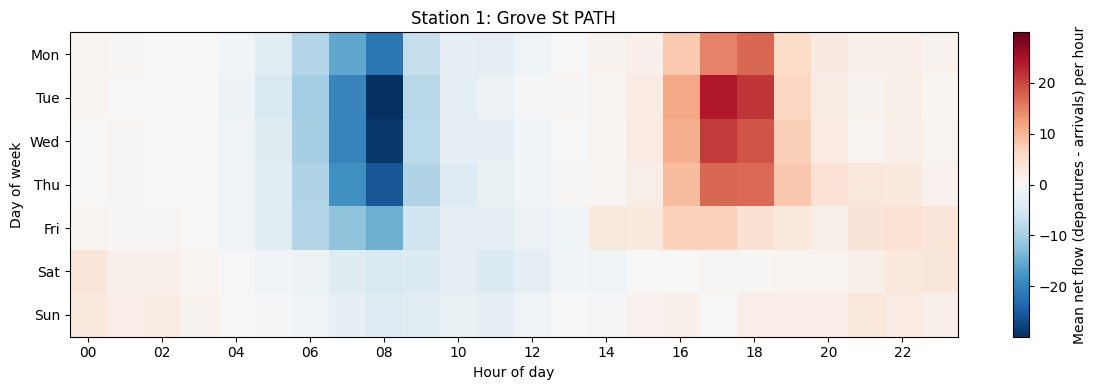

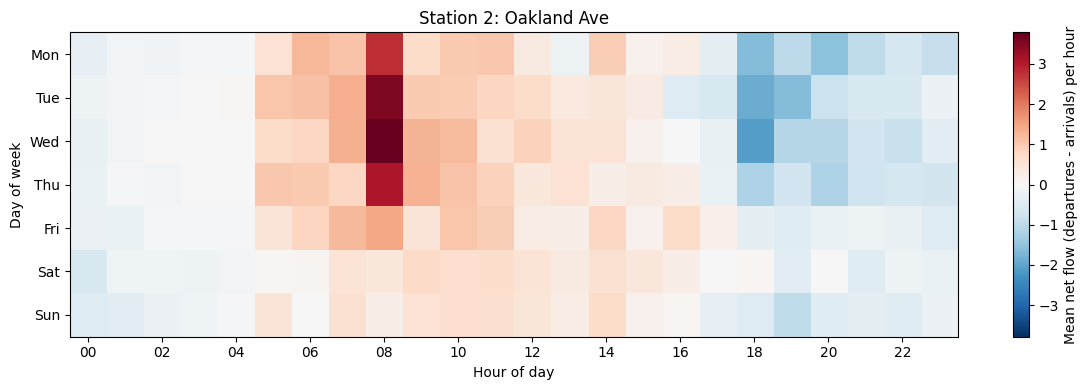

In [8]:
# Add day of week and net flow for heatmaps
heatmap_data = env_data.copy()
heatmap_data["date"] = pd.to_datetime(heatmap_data["date"])
dow_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
heatmap_data["dow"] = pd.Categorical(heatmap_data["date"].dt.day_name().str[:3], categories=dow_order, ordered=True)

# Net flow = departures - arrivals
heatmap_data["net_s1"] = heatmap_data["d_s1"] - heatmap_data["r_s1"]
heatmap_data["net_s2"] = heatmap_data["d_s2"] - heatmap_data["r_s2"]


def plot_netflow_heatmap(data, col, station_name):
    pivot = (data
        .groupby(["dow", "hour"], observed=False)[col]
        .mean()
        .unstack()
        .reindex(dow_order))

    lim = np.nanmax(np.abs(pivot.values))
    plt.figure(figsize=(12, 4))
    plt.imshow(pivot, aspect="auto", cmap="RdBu_r", vmin=-lim, vmax=lim)
    plt.colorbar(label="Mean net flow (departures - arrivals) per hour")
    plt.title(station_name)
    plt.xlabel("Hour of day")
    plt.ylabel("Day of week")
    plt.xticks(range(0, 24, 2),[f"{h:02d}" for h in range(0, 24, 2)])
    plt.yticks(range(len(dow_order)), dow_order)
    plt.tight_layout()
    plt.show()


s1_name = station_info.loc[ station_info["station_label"] == "s1","station_name"].iloc[0]
s2_name = station_info.loc[station_info["station_label"] == "s2","station_name"].iloc[0]

plot_netflow_heatmap(heatmap_data, "net_s1", f"Station 1: {s1_name}")
plot_netflow_heatmap(heatmap_data, "net_s2", f"Station 2: {s2_name}")

**2. Inventory Simulation on a Real Day**

-   Without rebalancing, both stations experience inventory shortages at different times of the day. 
-   Grove St PATH has large unmet demand in the late afternoon, while Oakland Ave runs out of bikes earlier in the day. 
-   System cannot fully satisfy hourly demand, supporting the need for an RL-based rebalancing policy.

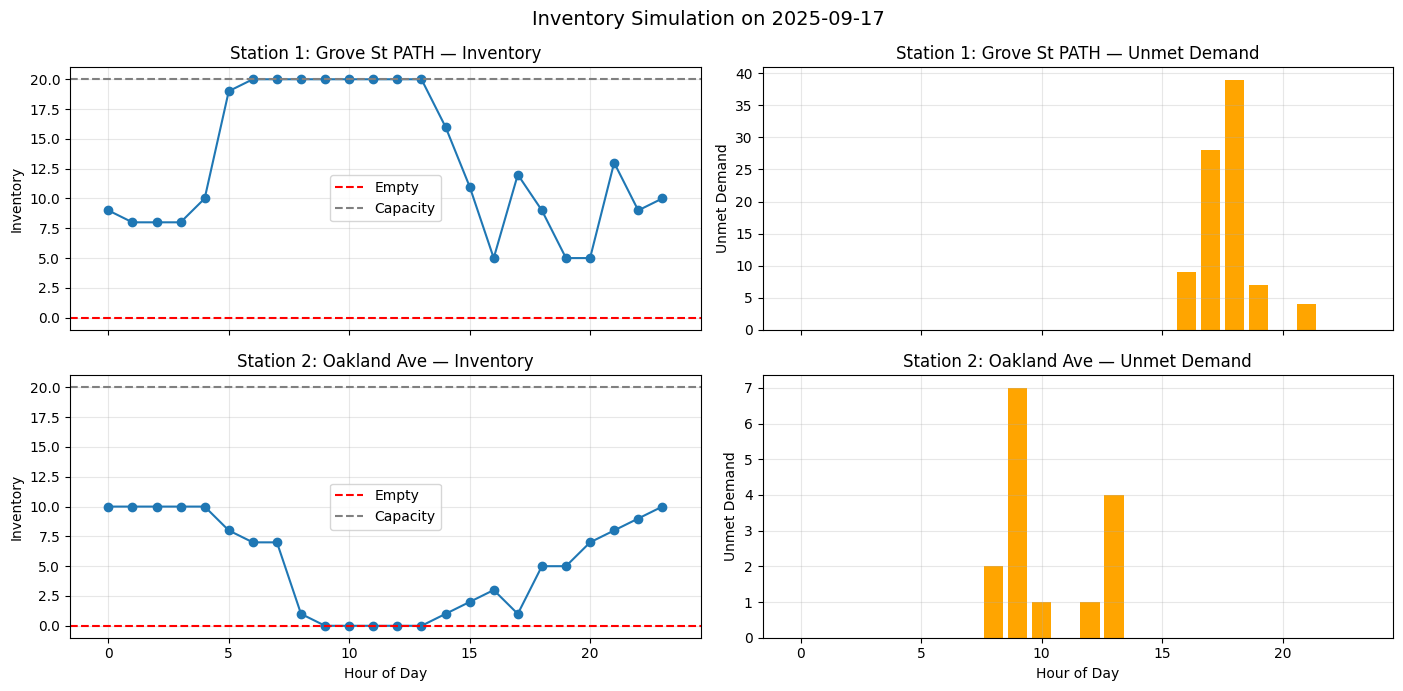

In [34]:
# Simulate inventory under do-nothing policy
plot_day = "2025-09-17" 
capacity = 20
initial_inventory = 10
day_data = env_data.copy()
day_data["date"] = pd.to_datetime(day_data["date"])
day_df = (day_data[day_data["date"] == plot_day].sort_values("hour").copy())
inventory = np.array([initial_inventory, initial_inventory])
inventory_history = []
unmet_history = []

for _, row in day_df.iterrows():
    departures = np.array([row["d_s1"], row["d_s2"]])
    arrivals = np.array([row["r_s1"], row["r_s2"]])

    served = np.minimum(inventory, departures)
    unmet = departures - served

    inventory = inventory - served + arrivals
    inventory = np.clip(inventory, 0, capacity)

    inventory_history.append(inventory.copy())
    unmet_history.append(unmet.copy())

inventory_history = np.array(inventory_history)
unmet_history = np.array(unmet_history)

fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True)
for i in [0, 1]:
    station_name = station_info.loc[station_info["station_label"] == f"s{i+1}","station_name"].iloc[0]

    axes[i, 0].plot(day_df["hour"], inventory_history[:, i], marker="o")
    axes[i, 0].axhline(0, linestyle="--", color="red", label="Empty")
    axes[i, 0].axhline(capacity, linestyle="--", color="gray", label="Capacity")
    axes[i, 0].set_title(f"Station {i+1}: {station_name} — Inventory")
    axes[i, 0].set_ylabel("Inventory")
    axes[i, 0].grid(alpha=0.3)
    axes[i, 0].legend()
    axes[i, 1].bar(day_df["hour"], unmet_history[:, i], color="orange")
    axes[i, 1].set_title(f"Station {i+1}: {station_name} — Unmet Demand")
    axes[i, 1].set_ylabel("Unmet Demand")
    axes[i, 1].grid(alpha=0.3)

for ax in axes[-1, :]:
    ax.set_xlabel("Hour of Day")

fig.suptitle(f"Inventory Simulation on {plot_day}", fontsize=14)
plt.tight_layout()
plt.show()

## Train/test split
Use data from 2025-01-01 to 2026-01-31 for training, and data from 2026-02-01 to 2026-02-28 for testing

In [ ]:
# Split hourly data into train and test sets
env_data["date"] = pd.to_datetime(env_data["date"])
train_data = env_data[(env_data["date"] >= "2025-01-01") &(env_data["date"] <= "2026-01-31")].copy()
test_data = env_data[(env_data["date"] >= "2026-02-01") &(env_data["date"] <= "2026-02-28")].copy()

print("Train hourly data shape:", train_data.shape) # 396 days * 24 hours = 9504 rows, 4 flow columns
print("Test hourly data shape:", test_data.shape) # 28 days * 24 hours = 672 rows, 4 flow columns

saved to data/processed folder

In [ ]:
train_data.to_csv(PROCESSED_DIR / "train_hourly.csv", index=False)
test_data.to_csv(PROCESSED_DIR / "test_hourly.csv", index=False)
station_info.to_csv(PROCESSED_DIR / "station_info.csv", index=False)